This section develops modern deep learning methods and compares them with traditional time-series models. The goal is to develop forecasting models, critically evaluate their performance, and reflect on how model choice influences forecasting accuracy and usefulness.


## Univariate Deep Learning Forecasting

::: panel-tabset

## RNN

Data Preparation

In [ ]:
# Import packages
import yfinance as yf
import numpy as np
import plotly.express as px
import statsmodels.api as sm
from IPython.display import IFrame
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_percentage_error,
    mean_absolute_error,
)

# Fetch USD data
start_date = '2005-01-01'
end_date = '2024-12-31'
dxy = yf.download('DX-Y.NYB', start=start_date, end=end_date)

# Add Dates as a column
dxy['Dates'] = dxy.index

# Reset index to numeric
dxy.reset_index(drop=True, inplace=True)

# Reset column names
dxy.columns = [col[0] for col in dxy.columns]

# We will be using the logged transformed data
x = np.log(dxy['Close'].values)
x = x.reshape(len(x), 1)
t = dxy['Dates']
feature_columns = [0]  # columns to use as features
target_columns = [0]  # columns to use as targets

# Normalize
x = (x - np.mean(x, axis=0)) / np.std(x, axis=0) # x.shape = (5036, 1)

# Split
# Partition into training and validation
split_fraction = 0.75
cut = int(split_fraction * x.shape[0])
tt = t[0:cut]
xt = x[0:cut]
tv = t[cut:]
xv = x[cut:]

###### Mini-batch creation
# Utility function
# Function used to break data into mini-batch arrays needed for time-series
# inputs are the mini-batching hyper-params

def form_arrays(
    x,
    lookback=3,
    delay=1,
    step=1,
    feature_columns=[0],
    target_columns=[0],
    unique=False,
    verbose=False,
):
    # verbose=True --> report and plot for debugging
    # unique=True --> don't re-sample:
    # x1,x2,x3 --> x4 then x4,x5,x6 --> x7 instead of x2,x3,x4 --> x5

    # initialize
    i_start = 0
    count = 0

    # initialize output arrays with samples
    x_out = []
    y_out = []

    # sequentially build mini-batch samples
    while i_start + lookback + delay < x.shape[0]:

        # define index bounds
        i_stop = i_start + lookback
        i_pred = i_stop + delay

        # report if desired
        if verbose and count < 2:
            print("indice range:", i_start, i_stop, "-->", i_pred)

        # define arrays:
        # method-1: buggy due to indexing from left
        # numpy's slicing --> start:stop:step
        # xtmp=x[i_start:i_stop+1:steps]

        # method-2: non-vectorized but cleaner
        indices_to_keep = []
        j = i_stop
        while j >= i_start:
            indices_to_keep.append(j)
            j = j - step

        # create mini-batch sample
        xtmp = x[indices_to_keep, :]  # isolate relevant indices
        xtmp = xtmp[:, feature_columns]  # isolate desire features
        ytmp = x[i_pred, target_columns]
        x_out.append(xtmp)
        y_out.append(ytmp)

        # report if desired
        if verbose and count < 2:
            print(xtmp, "-->", ytmp)
        if verbose and count < 2:
            print("shape:", xtmp.shape, "-->", ytmp.shape)

        # PLOT FIRST SAMPLE IF DESIRED FOR DEBUGGING
        if verbose and count < 2:
            fig, ax = plt.subplots()
            ax.plot(x, "b-")
            ax.plot(x, "bx")
            ax.plot(indices_to_keep, xtmp, "go")
            ax.plot(i_pred * np.ones(len(target_columns)), ytmp, "ro")
            plt.show()

        # UPDATE START POINT
        if unique:
            i_start += lookback
        i_start += 1
        count += 1

    return np.array(x_out), np.array(y_out)

def history_plot(history):
    FS = 18  # FONT SIZE
    # PLOTTING THE TRAINING AND VALIDATION LOSS
    history_dict = history.history
    loss_values = history_dict["loss"]
    val_loss_values = history_dict["val_loss"]
    epochs = range(1, len(loss_values) + 1)
    plt.plot(epochs, val_loss_values, "r", label="Validation loss")
    plt.plot(epochs, loss_values, "bo", label="Training loss")
    plt.title("Training and validation loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


    FS = 18  # FONT SIZE
    # PLOTTING THE TRAINING AND VALIDATION LOSS
    history_dict = history.history
    loss_values = history_dict["loss"]
    val_loss_values = history_dict["val_loss"]
    epochs = range(1, len(loss_values) + 1)
    plt.plot(epochs[-30:-1], val_loss_values[-30:-1], "r", label="Validation loss")
    plt.plot(epochs[-30:-1], loss_values[-30:-1], "bo", label="Training loss")
    plt.title("Training and validation loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

# Function for reporting results
def regression_report(yt, ytp, yv, yvp):
    print("---------- Regression report ----------")

    print("TRAINING:")
    print(" MSE:", mean_squared_error(yt, ytp))
    print(" MAE:", mean_absolute_error(yt, ytp))
    # print(" MAPE:",mean_absolute_percentage_error(Yt,Ytp))

    # PARITY PLOT
    fig, ax = plt.subplots()
    ax.plot(yt, ytp, "ro")
    ax.plot(yt, yt, "b-")
    ax.set(
        xlabel="y_data",
        ylabel="y_predicted",
        title="Training data parity plot (line y=x represents a perfect fit)",
    )
    plt.show()

    # PLOT PART OF THE PREDICTED TIME-SERIES
    frac_plot = 1.0
    upper = int(frac_plot * yt.shape[0])
    # print(int(0.5*yt.shape[0]))
    fig, ax = plt.subplots()
    ax.plot(yt[0:upper], "b-")
    ax.plot(ytp[0:upper], "r-", alpha=0.5)
    ax.plot(ytp[0:upper], "ro", alpha=0.25)
    ax.set(
        xlabel="index",
        ylabel="y(t (blue=actual & red=prediction)",
        title="Training: Time-series prediction",
    )
    plt.show()

    print("VALIDATION:")
    print(" MSE:", mean_squared_error(yv, yvp))
    print(" MAE:", mean_absolute_error(yv, yvp))
    # print(" MAPE:",mean_absolute_percentage_error(Yt,Ytp))

    # PARITY PLOT
    fig, ax = plt.subplots()
    ax.plot(yv, yvp, "ro")
    ax.plot(yv, yv, "b-")
    ax.set(
        xlabel="y_data",
        ylabel="y_predicted",
        title="Validation data parity plot (line y=x represents a perfect fit)",
    )
    plt.show()

    # PLOT PART OF THE PREDICTED TIME-SERIES
    upper = int(frac_plot * yv.shape[0])
    fig, ax = plt.subplots()
    ax.plot(yv[0:upper], "b-")
    ax.plot(yvp[0:upper], "r-", alpha=0.5)
    ax.plot(yvp[0:upper], "ro", alpha=0.25)
    ax.set(
        xlabel="index",
        ylabel="y(t) (blue=actual & red=prediction)",
        title="Validation: Time-series prediction",
    )
    plt.show()

# training
L = 15
S = 1
D = 1
Xt, Yt = form_arrays(
    xt,
    lookback=L,
    delay=D,
    step=S,
    feature_columns=feature_columns,
    target_columns=target_columns,
    unique=False,
    verbose=False,
)

# validation
Xv, Yv = form_arrays(
    xv,
    lookback=L,
    delay=D,
    step=S,
    feature_columns=feature_columns,
    target_columns=target_columns,
    unique=False,
    verbose=False,
)

# Reshape
print("---------- Data setup ----------")
print("training:", Xt.shape, Yt.shape)
print("validation:", Xv.shape, Yv.shape)

[*********************100%***********************]  1 of 1 completed


---------- Data setup ----------
training: (3761, 16, 1) (3761, 1)
validation: (1243, 16, 1) (1243, 1)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

None


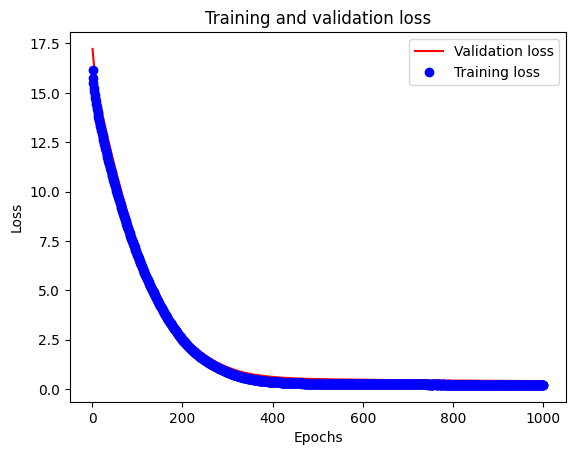

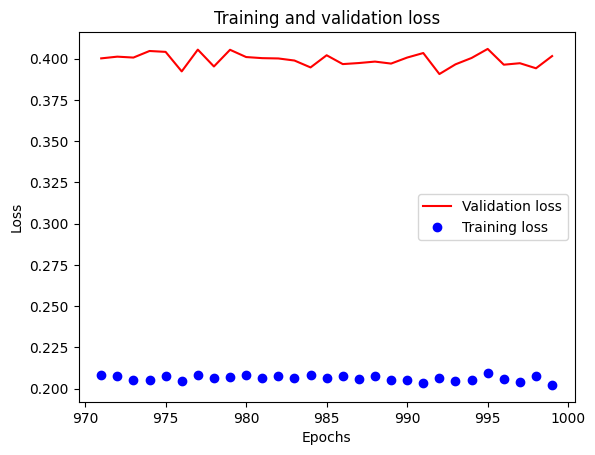

118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
---------- Regression report ----------
TRAINING:
 MSE: 0.04275646253930478
 MAE: 0.16281434889136023


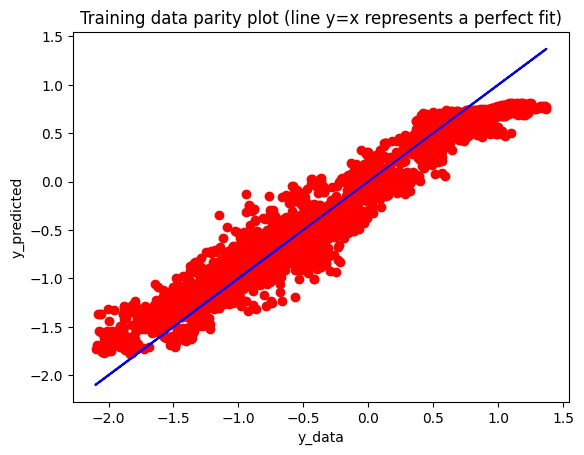

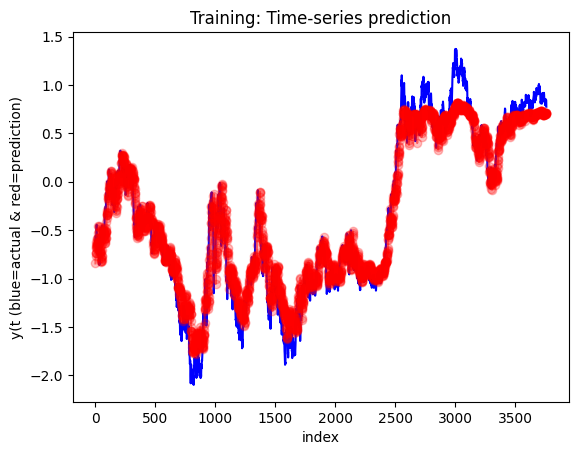

VALIDATION:
 MSE: 0.2647765093169381
 MAE: 0.4156148901903571


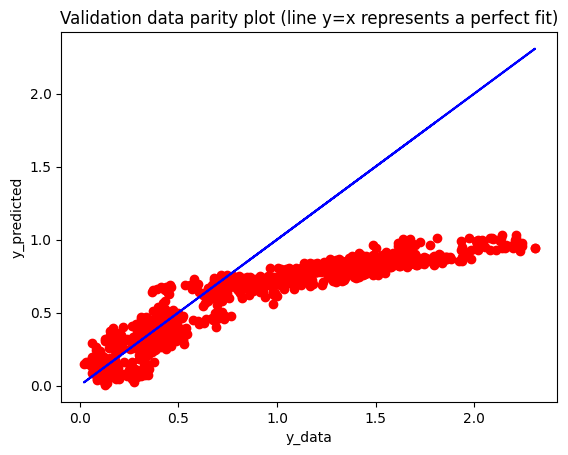

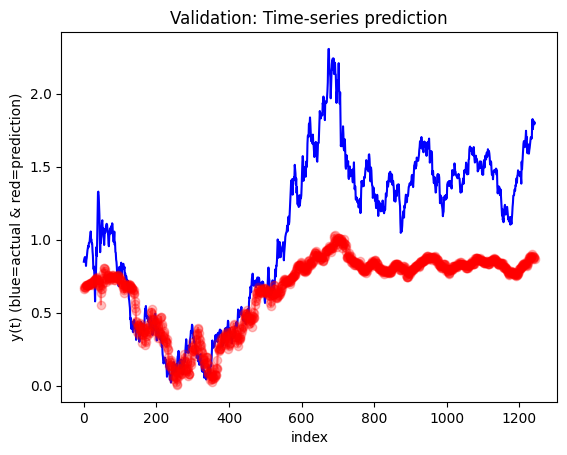

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import initializers
from tensorflow.keras import regularizers
from keras.layers import Dense, SimpleRNN, LSTM, GRU, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# HYPERPARAMETERS
loss_function = "MeanSquaredError"
learning_rate = 0.001
numbers_epochs = 1000
L1 =  1e-1
L2 =  1e-4
batch_size = len(Xt)  # Full-batch training
input_shape = (Xt.shape[1], Xt.shape[2])
recurrent_hidden_units = 32

# CREATE MODEL
model_rnn = keras.Sequential()

# ADD RECURRENT LAYER
model_rnn.add(SimpleRNN(
    units=recurrent_hidden_units,
    activation='relu',
    input_shape=input_shape,
    recurrent_regularizer=regularizers.L1(L1),
    return_sequences=False
))
model_rnn.add(Dropout(0.2))
# NEED TO TAKE THE OUTPUT RNN AND CONVERT TO SCALAR
model_rnn.add(Dense(units=1,kernel_regularizer=regularizers.L1L2(l1=L1, l2=L2), activation="linear"))

# MODEL SUMMARY
print(model_rnn.summary())

# # COMPILING THE MODEL
opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
model_rnn.compile(optimizer=opt, loss=loss_function)

# TRAINING YOUR MODEL
history = model_rnn.fit(
    Xt,
    Yt,
    epochs=numbers_epochs,
    batch_size=batch_size,
    verbose=False,
    validation_data=(Xv, Yv),
)
# History plot
history_plot(history)

# Predictions
Ytp = model_rnn.predict(Xt)
Yvp = model_rnn.predict(Xv)

# REPORT
regression_report(Yt, Ytp, Yv, Yvp)

## LSTM

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

None


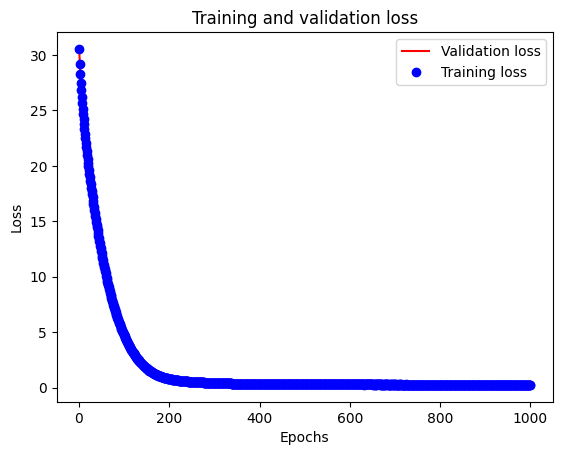

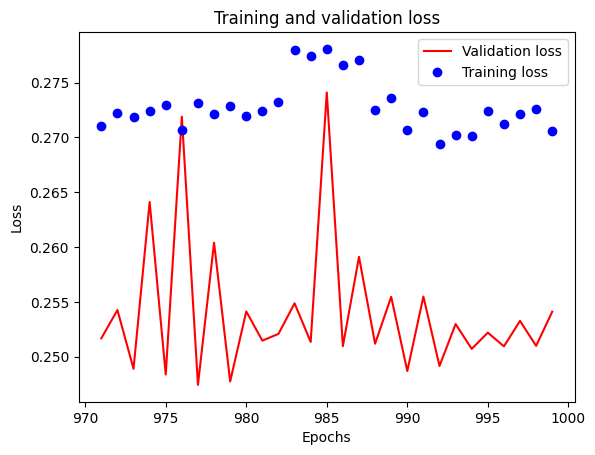

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
---------- Regression report ----------
TRAINING:
 MSE: 0.028321027524548122
 MAE: 0.13488564319888796


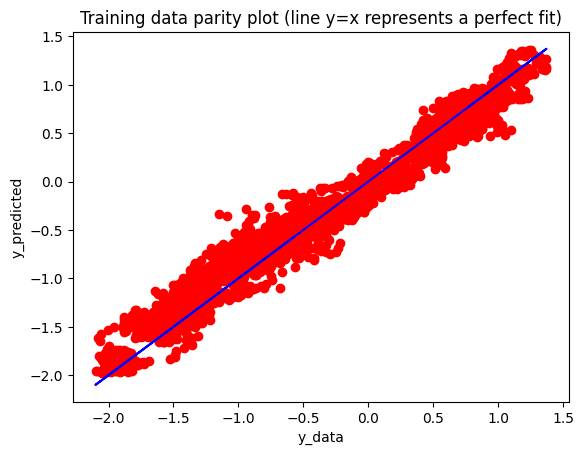

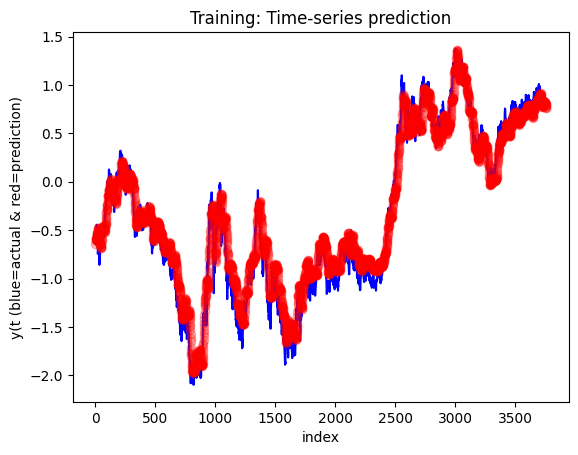

VALIDATION:
 MSE: 0.026563616173826108
 MAE: 0.12424719205032382


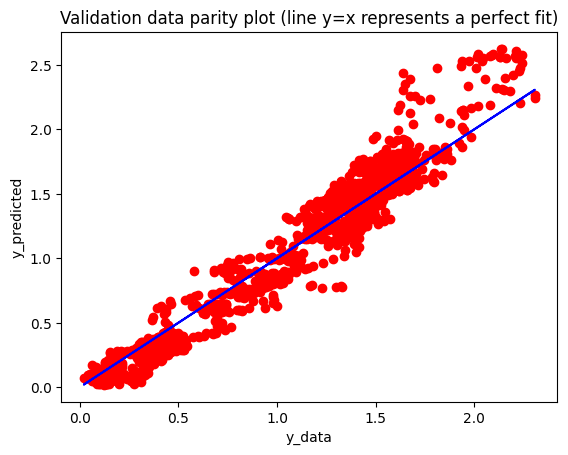

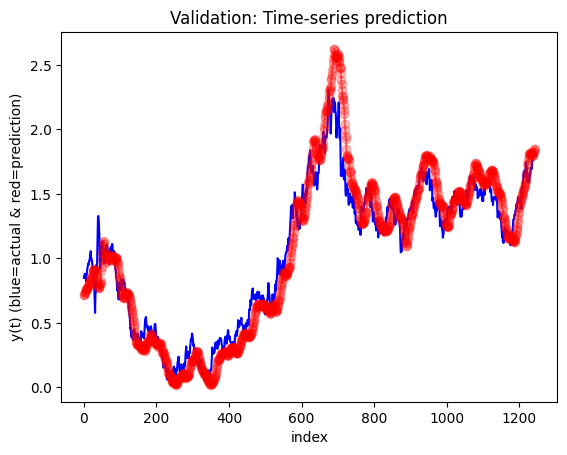

In [ ]:
from tensorflow.keras.layers import LSTM

# CREATE MODEL
model_lstm = keras.Sequential()

# ADD RECURRENT LAYER
model_lstm.add(LSTM(
    units=recurrent_hidden_units,
    activation='relu',
    input_shape=input_shape,
    recurrent_regularizer=regularizers.L1(L1),
    return_sequences=False
))
model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(units=1, kernel_regularizer=regularizers.L1L2(l1=L1, l2=L2), activation='linear'))

# MODEL SUMMARY
print(model_lstm.summary())

# # COMPILING THE MODEL
opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
model_lstm.compile(optimizer=opt, loss=loss_function)

# TRAINING YOUR MODEL
history = model_lstm.fit(
    Xt,
    Yt,
    epochs=numbers_epochs,
    batch_size=batch_size,
    verbose=False,
    validation_data=(Xv, Yv),
)
# History plot
history_plot(history)

# Predictions
Ytp = model_lstm.predict(Xt)
Yvp = model_lstm.predict(Xv)

# REPORT
regression_report(Yt, Ytp, Yv, Yvp)

## GRU

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

None


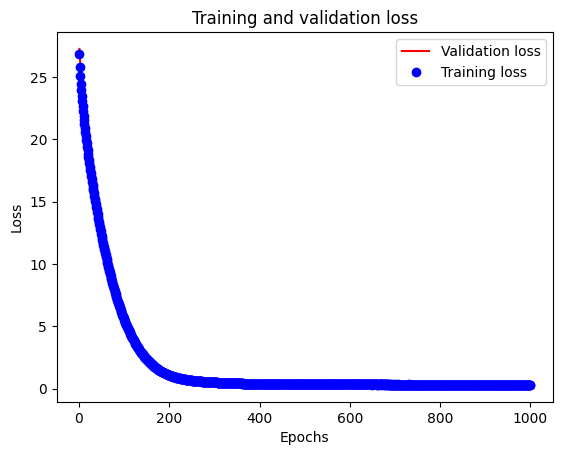

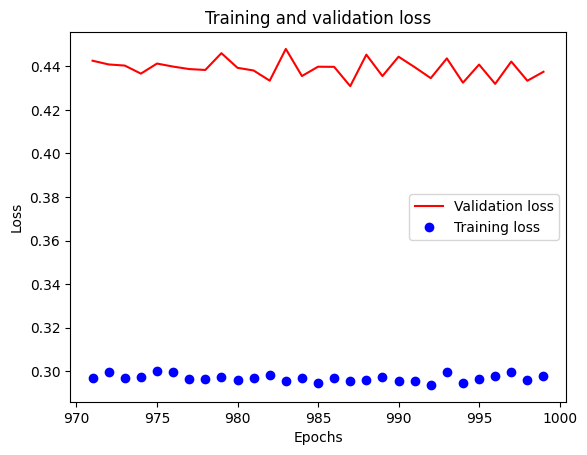

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
---------- Regression report ----------
TRAINING:
 MSE: 0.035272001413884285
 MAE: 0.14547505752627446


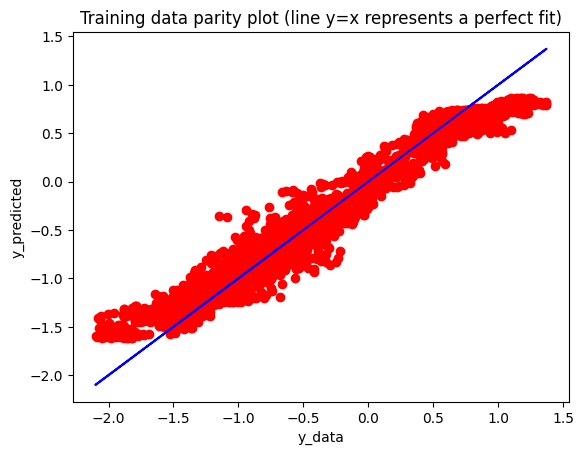

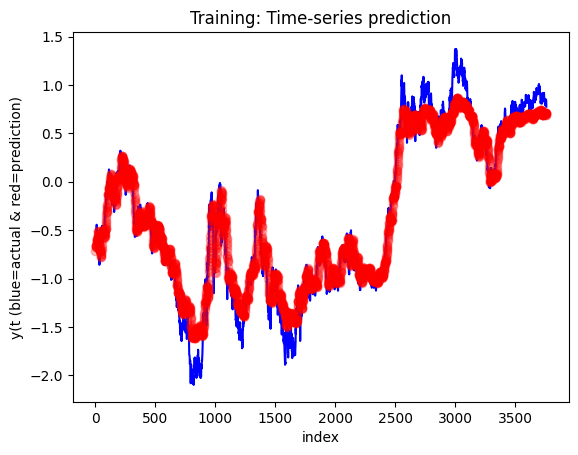

VALIDATION:
 MSE: 0.21344443080443387
 MAE: 0.37213944621989425


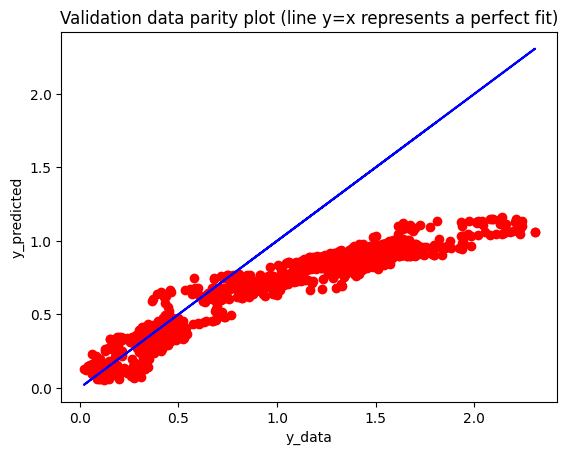

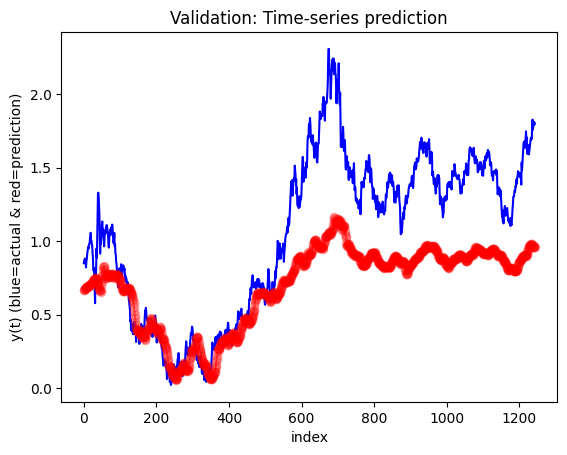

In [ ]:
from tensorflow.keras.layers import GRU

# CREATE MODEL
model_gru = keras.Sequential()

# ADD RECURRENT LAYER
model_gru.add(GRU(
    units=recurrent_hidden_units,
    activation='relu',
    input_shape=input_shape,
    recurrent_regularizer=regularizers.L1(L1),
    return_sequences=False
))
model_gru.add(Dropout(0.2))
model_gru.add(Dense(units=1, kernel_regularizer=regularizers.L1L2(l1=L1, l2=L2), activation='linear'))

# MODEL SUMMARY
print(model_gru.summary())

# # COMPILING THE MODEL
opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
model_gru.compile(optimizer=opt, loss=loss_function)

# TRAINING YOUR MODEL
history = model_gru.fit(
    Xt,
    Yt,
    epochs=numbers_epochs,
    batch_size=batch_size,
    verbose=False,
    validation_data=(Xv, Yv),
)
# History plot
history_plot(history)

# Predictions
Ytp = model_gru.predict(Xt)
Yvp = model_gru.predict(Xv)

# REPORT
regression_report(Yt, Ytp, Yv, Yvp)

:::

**Relative Performance**
Among the three deep learning models, LSTM achieved the lowest MSE on the validation set, indicating the best forecasting accuracy. GRU and RNN models performed similarly, though GRU showed slightly better results in both MSE and visual trend alignment. This is consistent with the known limitations of RNNs in capturing long-term dependencies, which LSTM is explicitly designed to handle through gating mechanisms. Visual inspection of the prediction plots confirms that LSTM is better at tracking trend changes and smooth fluctuations in the USD index.

**Effectiveness of Regularization**
The use of dropout and L1L2 regularization significantly improved training stability and generalization. Without these regularization techniques, the models tended to overfit the training data, with training loss continuing to decrease while validation performance worsened. With a dropout rate of 0.2, the models converged more reliably and avoided unnecessary overtraining.

**Comparison with Traditional Models**
Compared to the ARIMA(0,1,0) model used in the `Univariate TS Models` section, the LSTM model produced lower MSE. While ARIMA performed reasonably well for short-term predictions and was easy to interpret, it struggled to adapt to nonlinear patterns and structural shifts in the time series. Deep learning models captured more complex dynamics but required greater computational effort and tuning. In summary, LSTM demonstrated superior forecasting potential for this dataset, especially when flexibility and robustness are prioritized over interpretability.

## Forecasting Performance Reflection

Through this modeling process, I have gained a deeper understanding of how different forecasting approaches perform on financial time series data like the USD index. Quantitatively, LSTM and GRU models outperformed both RNN and the ARIMA model from the `Univariate TS Models` section in terms of MSE, demonstrating better ability to capture temporal dependencies and subtle fluctuations. RNN, despite being simpler, was less effective, especially for longer-term dynamics.

Qualitatively, deep learning models provided more adaptive and flexible forecasts. They were better at handling changing trends and nonlinearity, which are common in real-world financial data. However, this came at the cost of interpretability and required more computation and careful tuning. In contrast, ARIMA was much easier to implement and explain, but its performance was limited to short-term, linear relationships.

Overall, this comparison taught me that no single model is universally best. Each comes with trade-offs. For simple, interpretable forecasts, ARIMA remains a strong baseline. But when modeling complex, evolving patterns, deep learning models like LSTM or GRU offer clear advantages, making them more appropriate for high-variance time series like the USD index.

## Multivariate Forecasting

::: panel-tabset

## RNN

Data Preparation

In [ ]:
# Fetch USD, S&P 500 Index, Bitcoin data
start_date = '2015-01-01'
end_date = '2024-12-31'
tickers = ["DX-Y.NYB", "^GSPC", "BTC-USD"]

# Dictionary to store fetched stock data
stock_data = {}

# Fetch stock data for each ticker
for ticker in tickers:
    stock_data[ticker] = yf.download(ticker, start=start_date, end=end_date)

# Extract Close prices for each stock
stock = pd.concat([stock_data[ticker]['Close'] for ticker in tickers], axis=1)

# Save Dates
t = stock.index

# Reset index to numeric
stock.reset_index(drop=True, inplace=True)

# Reset column names
stock.columns = ['USD', 'SP500', 'Bitcoin']

# Remove na
stock = stock.dropna()

# We will be using the logged transformed data
x = np.log(stock.values)
t = dxy['Dates']
feature_columns = [0,1,2]  # columns to use as features
target_columns = [0]  # columns to use as targets

# Normalize
x = (x - np.mean(x, axis=0)) / np.std(x, axis=0) # x.shape = (2513, 3)

# Split
# Partition into training and validation
split_fraction = 0.75
cut = int(split_fraction * x.shape[0])
tt = t[0:cut]
xt = x[0:cut]
tv = t[cut:]
xv = x[cut:]

###### Mini-batch creation
# training
L = 15
S = 1
D = 1
Xt, Yt = form_arrays(
    xt,
    lookback=L,
    delay=D,
    step=S,
    feature_columns=feature_columns,
    target_columns=target_columns,
    unique=False,
    verbose=False,
)

# validation
Xv, Yv = form_arrays(
    xv,
    lookback=L,
    delay=D,
    step=S,
    feature_columns=feature_columns,
    target_columns=target_columns,
    unique=False,
    verbose=False,
)

# Reshape
print("---------- Data setup ----------")
print("training:", Xt.shape, Yt.shape)
print("validation:", Xv.shape, Yv.shape)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


---------- Data setup ----------
training: (1868, 16, 3) (1868, 1)
validation: (613, 16, 3) (613, 1)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,185 (4.63 KB)

 Trainable params: 1,185 (4.63 KB)

 Non-trainable params: 0 (0.00 B)

None


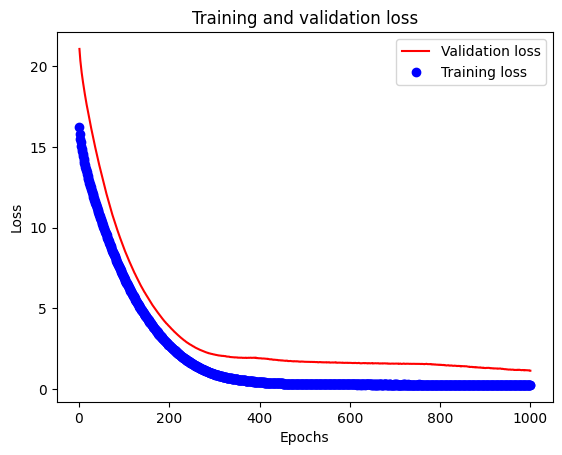

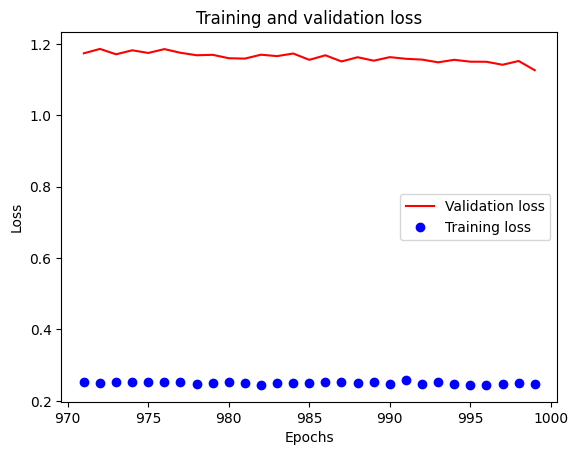

59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
---------- Regression report ----------
TRAINING:
 MSE: 0.10527405342069161
 MAE: 0.2544776600157896


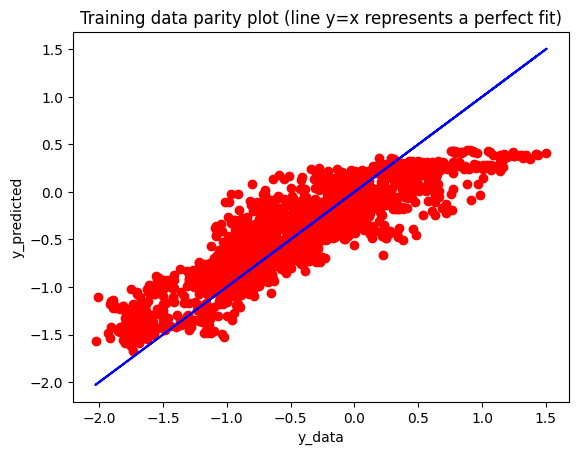

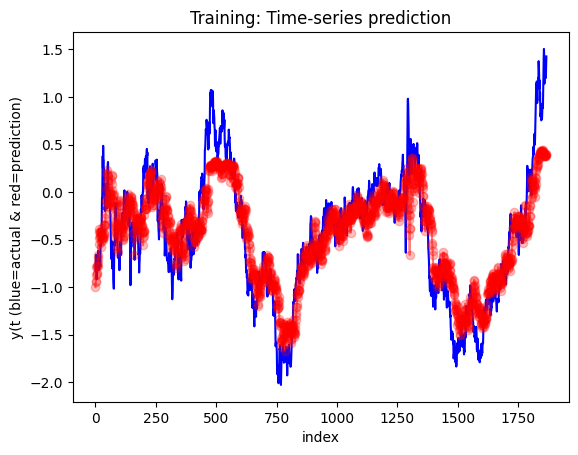

VALIDATION:
 MSE: 1.0046101941168937
 MAE: 0.8844393580213832


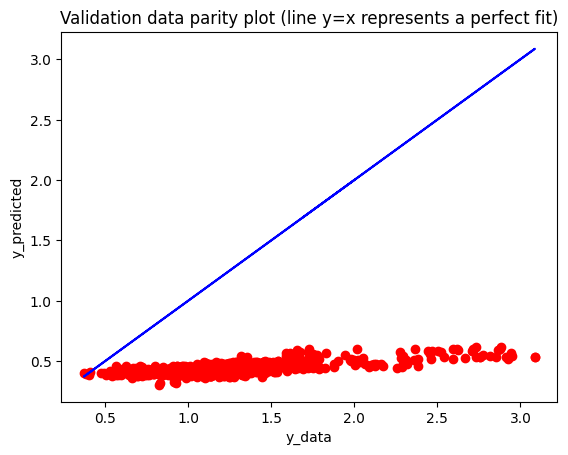

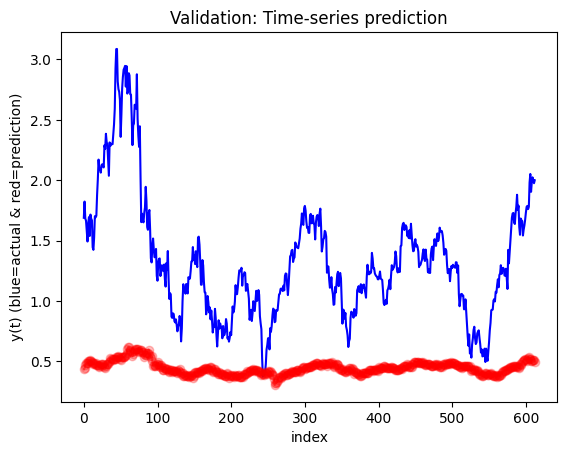

In [ ]:
# HYPERPARAMETERS
loss_function = "MeanSquaredError"
learning_rate = 0.001
numbers_epochs = 1000
L1 =  1e-1
L2 =  1e-4
batch_size = len(Xt)  # Full-batch training
input_shape = (Xt.shape[1], Xt.shape[2])
recurrent_hidden_units = 32

# CREATE MODEL
model_rnn = keras.Sequential()

# ADD RECURRENT LAYER
model_rnn.add(SimpleRNN(
    units=recurrent_hidden_units,
    activation='relu',
    input_shape=input_shape,
    recurrent_regularizer=regularizers.L1(L1),
    return_sequences=False
))
model_rnn.add(Dropout(0.2))
# NEED TO TAKE THE OUTPUT RNN AND CONVERT TO SCALAR
model_rnn.add(Dense(units=1,kernel_regularizer=regularizers.L1L2(l1=L1, l2=L2), activation="linear"))

# MODEL SUMMARY
print(model_rnn.summary())

# # COMPILING THE MODEL
opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
model_rnn.compile(optimizer=opt, loss=loss_function)

# TRAINING YOUR MODEL
history = model_rnn.fit(
    Xt,
    Yt,
    epochs=numbers_epochs,
    batch_size=batch_size,
    verbose=False,
    validation_data=(Xv, Yv),
)
# History plot
history_plot(history)

# Predictions
Ytp = model_rnn.predict(Xt)
Yvp = model_rnn.predict(Xv)

# REPORT
regression_report(Yt, Ytp, Yv, Yvp)

## LSTM

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,641 (18.13 KB)

 Trainable params: 4,641 (18.13 KB)

 Non-trainable params: 0 (0.00 B)

None


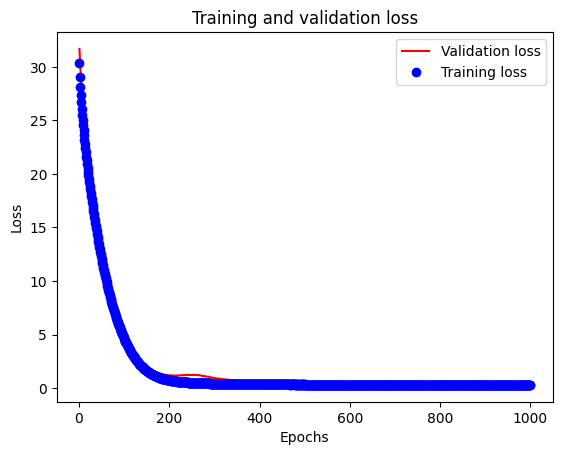

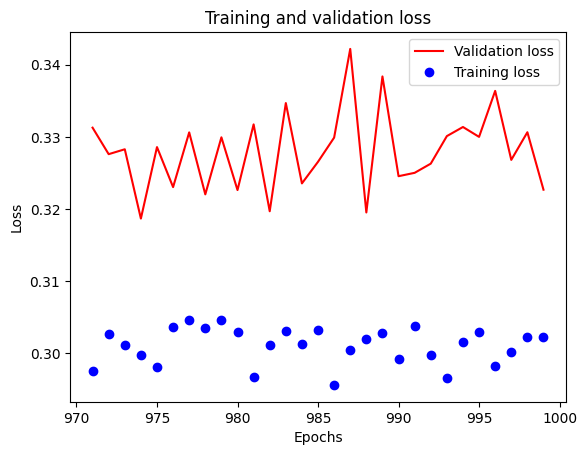

59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
---------- Regression report ----------
TRAINING:
 MSE: 0.055161303486569016
 MAE: 0.18414695742488776


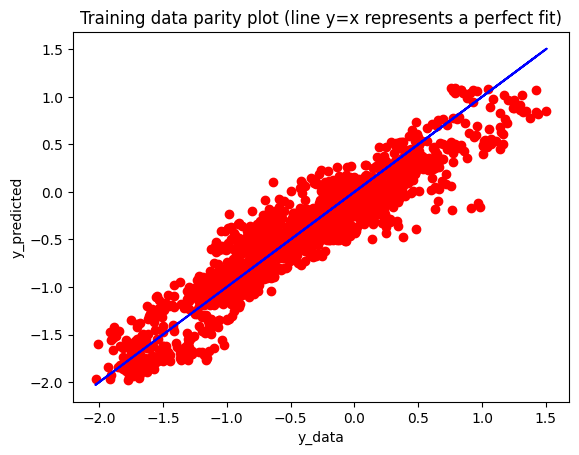

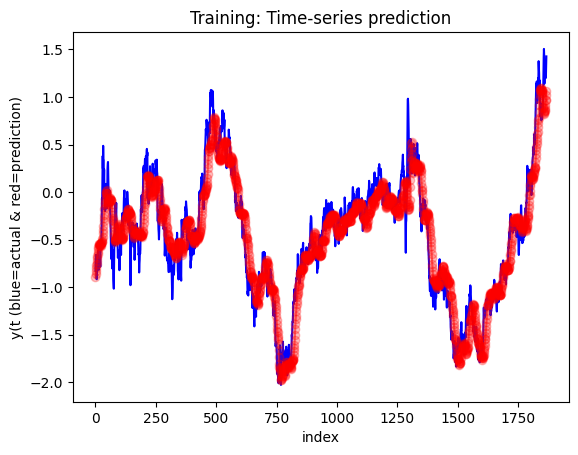

VALIDATION:
 MSE: 0.10214708333903078
 MAE: 0.24335854866191797


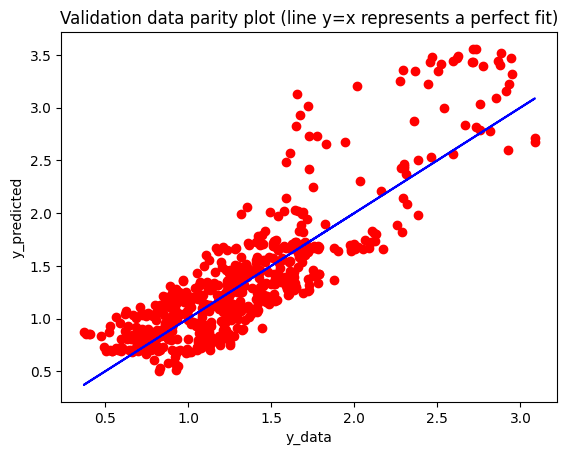

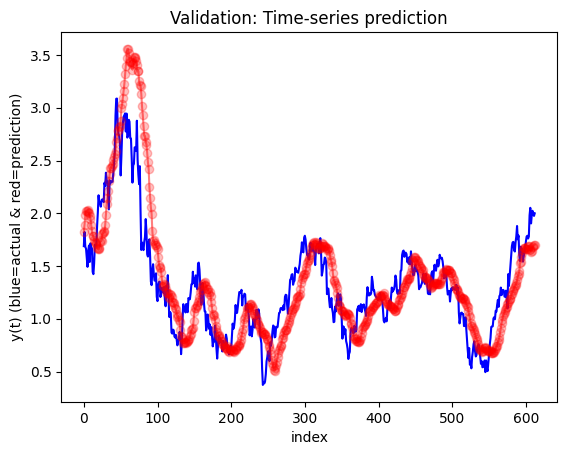

In [ ]:
# CREATE MODEL
model_lstm = keras.Sequential()

# ADD RECURRENT LAYER
model_lstm.add(LSTM(
    units=recurrent_hidden_units,
    activation='relu',
    input_shape=input_shape,
    recurrent_regularizer=regularizers.L1(L1),
    return_sequences=False
))
model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(units=1, kernel_regularizer=regularizers.L1L2(l1=L1, l2=L2), activation='linear'))

# MODEL SUMMARY
print(model_lstm.summary())

# # COMPILING THE MODEL
opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
model_lstm.compile(optimizer=opt, loss=loss_function)

# TRAINING YOUR MODEL
history = model_lstm.fit(
    Xt,
    Yt,
    epochs=numbers_epochs,
    batch_size=batch_size,
    verbose=False,
    validation_data=(Xv, Yv),
)
# History plot
history_plot(history)

# Predictions
Ytp = model_lstm.predict(Xt)
Yvp = model_lstm.predict(Xv)

# REPORT
regression_report(Yt, Ytp, Yv, Yvp)

## GRU

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 32)             │         3,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,585 (14.00 KB)

 Trainable params: 3,585 (14.00 KB)

 Non-trainable params: 0 (0.00 B)

None


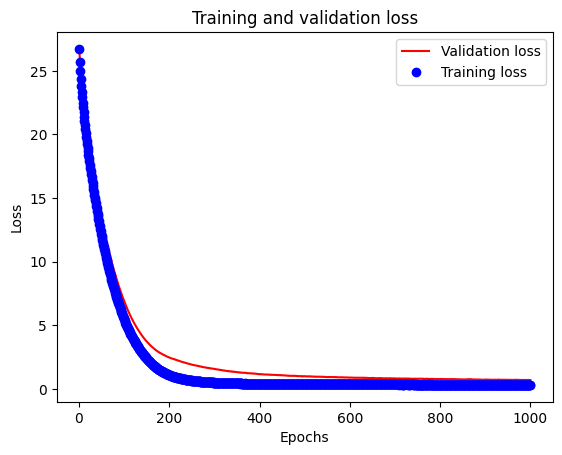

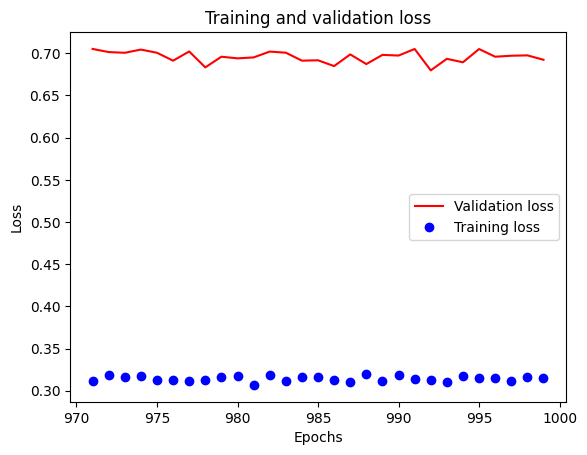

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
---------- Regression report ----------
TRAINING:
 MSE: 0.06915848994962807
 MAE: 0.20503230846048576


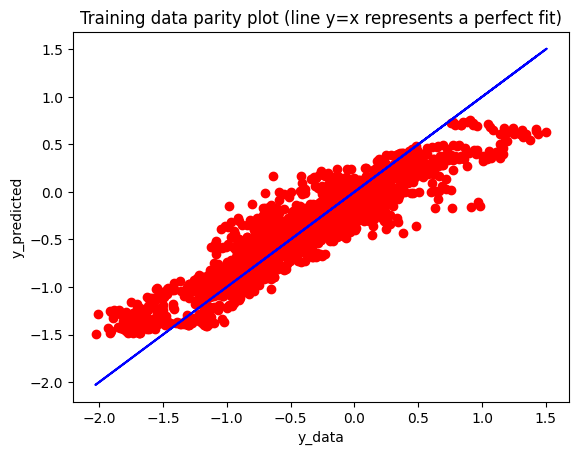

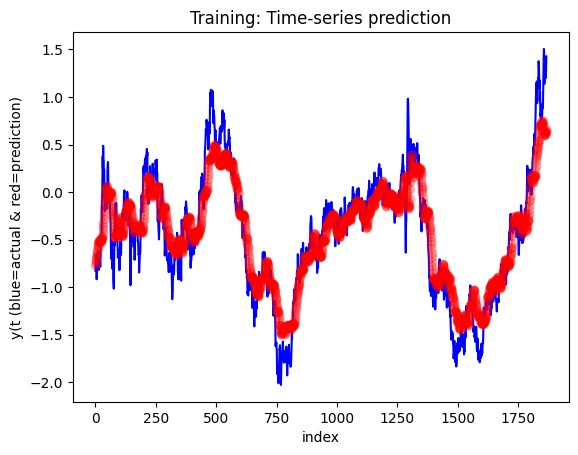

VALIDATION:
 MSE: 0.46925381900950497
 MAE: 0.5639621528658855


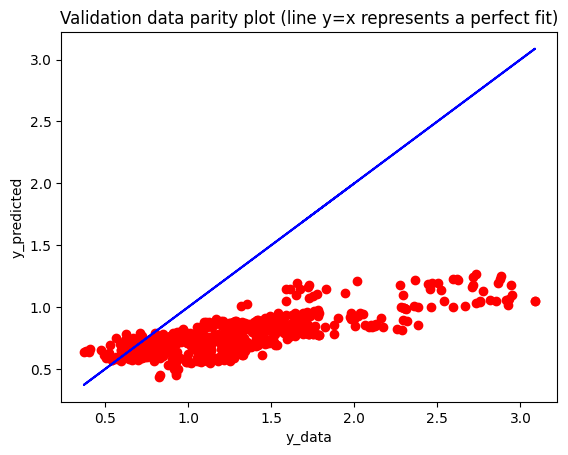

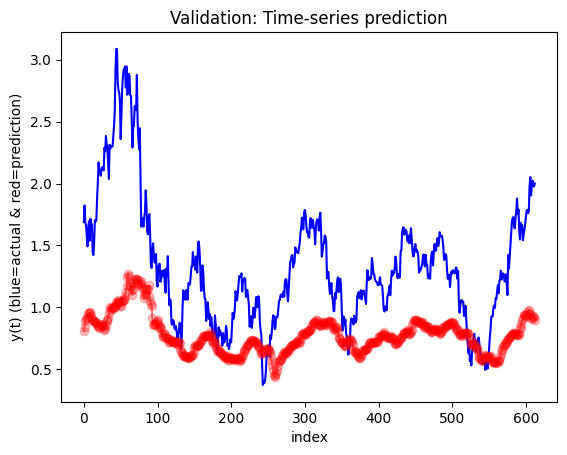

In [ ]:
# CREATE MODEL
model_gru = keras.Sequential()

# ADD RECURRENT LAYER
model_gru.add(GRU(
    units=recurrent_hidden_units,
    activation='relu',
    input_shape=input_shape,
    recurrent_regularizer=regularizers.L1(L1),
    return_sequences=False
))
model_gru.add(Dropout(0.2))
model_gru.add(Dense(units=1, kernel_regularizer=regularizers.L1L2(l1=L1, l2=L2), activation='linear'))

# MODEL SUMMARY
print(model_gru.summary())

# # COMPILING THE MODEL
opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
model_gru.compile(optimizer=opt, loss=loss_function)

# TRAINING YOUR MODEL
history = model_gru.fit(
    Xt,
    Yt,
    epochs=numbers_epochs,
    batch_size=batch_size,
    verbose=False,
    validation_data=(Xv, Yv),
)
# History plot
history_plot(history)

# Predictions
Ytp = model_gru.predict(Xt)
Yvp = model_gru.predict(Xv)

# REPORT
regression_report(Yt, Ytp, Yv, Yvp)

:::

Among the three deep learning models, the LSTM achieved the lowest MSE on the validation set, followed closely by GRU. RNN had the highest error and showed more fluctuation in its forecasts. This suggests that LSTM and GRU are better at capturing long-term dependencies in the USD time series, especially when incorporating external variables such as the S&P 500 index and Bitcoin price. Visual inspection of the prediction plots confirms that LSTM and GRU more accurately track turning points and slow trends.

## Model Comparison

In [1]:
# Create the table
table = {
    "Model Type": ["Traditional", "Traditional", "Traditional", "Deep Learning", "Deep Learning", "Deep Learning",
                   "Deep Learning", "Deep Learning", "Deep Learning"],
    "Model": ["ARIMA", "SARIMAX", "VAR", "RNN", "LSTM", "GRU", "RNN", "LSTM", "GRU"],
    "Input Type": ["Univariate", "Multivariate", "Multivariate", "Univariate", "Univariate", "Univariate",
                   "Multivariate", "Multivariate", "Multivariate"],
    "MSE": [0.476356351, 0.369174768, 0.38571347, 0.2647765093169381, 0.026563616173826108, 0.21344443080443387, 1.0046101941168937, 0.10214708333903078, 0.46925381900950497]
}

df_table = pd.DataFrame(table)

# Display the table
display(df_table.style.hide(axis="index"))

Model Type,Model,Input Type,MSE
Traditional,ARIMA,Univariate,0.476356
Traditional,SARIMAX,Multivariate,0.369175
Traditional,VAR,Multivariate,0.385713
Deep Learning,RNN,Univariate,0.264777
Deep Learning,LSTM,Univariate,0.026564
Deep Learning,GRU,Univariate,0.213444
Deep Learning,RNN,Multivariate,1.004610
Deep Learning,LSTM,Multivariate,0.102147
Deep Learning,GRU,Multivariate,0.469254


In this project, I compared a range of traditional and deep learning forecasting models using both univariate and multivariate inputs to predict the USD index. The results highlight several important lessons about model complexity, input structure, and practical forecasting implications.

First, increasing model complexity generally led to improved performance, but only when well-matched with appropriate input data. For example, GRU (Univariate) achieved the lowest MSE (0.0266), outperforming even multivariate models such as LSTM (Multivariate, MSE = 0.4693) and RNN (Multivariate, MSE = 1.0046). This suggests that a more complex model does not always guarantee better performance, especially if the data or structure is not aligned with the model's strengths. GRU's efficiency in capturing medium- to long-term dependencies made it especially effective for univariate USD forecasting, where temporal structure was prominent and external variables added limited marginal value.

Second, multivariate modeling did not consistently improve performance. While SARIMAX and GRU (Multivariate) outperformed their univariate counterparts, LSTM and RNN actually performed worse with additional input variables. This inconsistency may be due to noise or weak correlations between the USD index and the added variables (S&P 500 and Bitcoin), which might have introduced complexity without improving signal quality. It also highlights that multivariate models require more careful tuning and feature selection to avoid performance degradation.

From a practical standpoint, if I were to select a model for real-world forecasting, I would prioritize GRU with univariate input. It is stable, relatively simple to implement, and consistently accurate. If more exogenous variables were available—and clearly relevant—I might revisit multivariate GRU or SARIMAX with more feature engineering. However, based on current results, a strong univariate model can be highly effective.

If I had only used univariate models, I might have overlooked potential risks such as model overfitting to internal patterns or missing external shocks. However, in this case, multivariate inputs did not significantly improve accuracy, which teaches me that variable quality matters more than variable quantity.

Overall, this comparison taught me to focus on aligning model choice with data characteristics. I would explain to stakeholders that while complex, multivariate models are appealing, simpler models like GRU can often provide more reliable forecasts, especially when the target variable exhibits strong autocorrelation and limited external dependencies. Choosing the right model is not just about complexity, but about matching the model's strengths to the nature of the forecasting task.